# График производительности Task 15

Этот notebook строит график зависимости времени вычисления `Solve` от количества потоков.

Источник данных: `task15-thread-measurements-step-0.1.csv`.

По заданию:

- ось OX — время вычисления функции `Solve`, мс;
- ось OY — количество потоков.

In [4]:
#r "nuget:ScottPlot, 5.0.*"
#r "nuget: SkiaSharp.NativeAssets.Linux, 2.88.9"

using Microsoft.DotNet.Interactive.Formatting;
using ScottPlot;
using System.Globalization;
using System.IO;

Formatter.Register(typeof(ScottPlot.Plot), (plot, writer) =>
    writer.Write(((ScottPlot.Plot)plot).GetPngHtml(900, 600)), HtmlFormatter.MimeType);

Error: ScottPlot version 5.0.* cannot be added because version 5.0.56 was added previously.

In [5]:
var csvPath = "/home/wharrypa/OOP_C_sharp/OOP-C-/practice2026/task15-reports/task15-thread-measurements-step-0.1.csv";
var outputPath = "/home/wharrypa/OOP_C_sharp/OOP-C-/practice2026/task15-reports/task15-thread-chart.png";

var lines = File.ReadAllLines(csvPath).Skip(1);

var threads = new List<double>();
var times = new List<double>();

foreach (var line in lines)
{
    var parts = line.Split(',');

    threads.Add(double.Parse(parts[0], CultureInfo.InvariantCulture));
    times.Add(double.Parse(parts[1], CultureInfo.InvariantCulture));
}

Console.WriteLine($"Загружено замеров: {threads.Count}");

Загружено замеров: 15


График сохранён: /home/wharrypa/OOP_C_sharp/OOP-C-/practice2026/task15-reports/task15-thread-chart.png



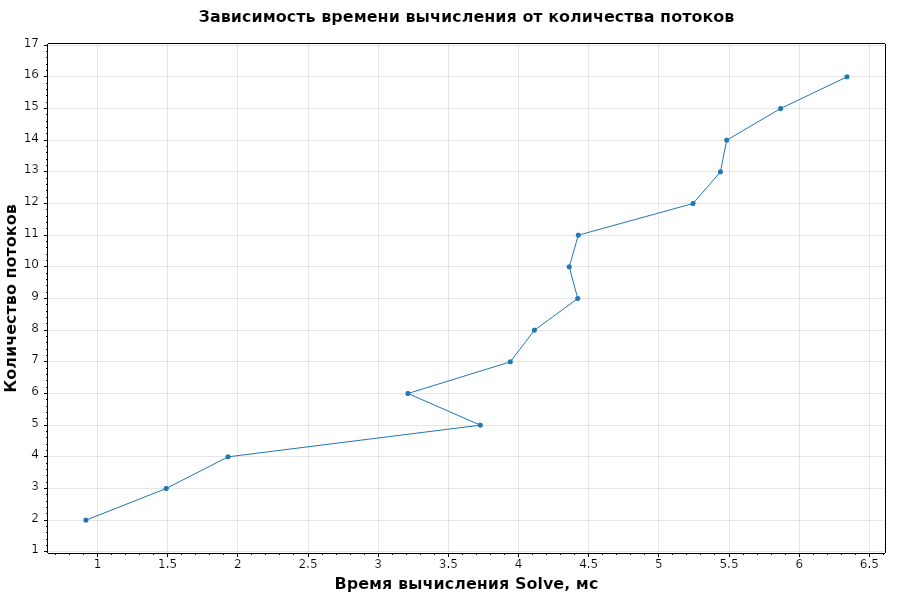

In [6]:
var plot = new Plot();

plot.Add.Scatter(
    xs: times.ToArray(),
    ys: threads.ToArray()
);

plot.Title("Зависимость времени вычисления от количества потоков");
plot.XLabel("Время вычисления Solve, мс");
plot.YLabel("Количество потоков");

plot.SavePng(outputPath, 900, 600);

Console.WriteLine($"График сохранён: {outputPath}");
plot